# Maximum Diversification

Builds the maximum-diversification portfolio on the same CRSP universe and
single-factor covariance used by minimum risk and risk parity. This notebook
covers MaxDiv; performance and risk-contribution diagnostics use the shared
`backtest.py` and `evaluation.py` modules.

| Section | Content |
|---|---|
| §1 | Setup and common data |
| §2 | Diversification ratio and the single-factor solution |
| §3 | One rebalance: QP and closed-form comparison |
| §4 | Full rolling backtest |
| §5 | Performance table |
| §6 | Cumulative returns, drawdowns and subperiods |
| §7 | Diversification and risk concentration |

Portfolio construction lives in `max_diversification.py`.

## 1. Setup and data

In [1]:
import os, sys, time
from pathlib import Path

if not Path("estimation.py").exists() and Path("../estimation.py").exists():
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from estimation import estimate_single_factor
from backtest import select_universe, rolling_backtest, summarize
from max_diversification import (max_diversification, max_diversification_closed_form,
                                diversification_ratio, optimality_residuals)
from evaluation import (returns_from_panel, performance_table, subperiod_table,
                         cumulative_returns, drawdowns, estimate_covs,
                         risk_concentration, check_alignment)

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 1.5,
})
COLORS = {"max_div": "#eb6834", "ew": "#eda100"}
LABELS = {"max_div": "Maximum diversification", "ew": "Equally weighted"}

Same data preparation as the minimum-risk and risk-parity notebooks: NYSE / NYSE
American / Nasdaq, French returns divided by 100, and `yyyymm` month keys.
At each rebalance, the shared loop selects the largest 500 eligible stocks with
60 months of complete history. The available extract identifies exchanges but
does not provide the share-type field for a full common-stock filter.

In [2]:
crsp = pd.read_parquet("data/crsp_msf_v2.parquet",
                       columns=["permno", "yyyymm", "mthret", "mthcap", "primaryexch"])
crsp = crsp[crsp.primaryexch.isin(["N", "A", "Q"])]
assert not crsp.duplicated(["yyyymm", "permno"]).any()
ff = pd.read_csv("data/MktRf.csv", index_col=0)

rets = crsp.pivot(index="yyyymm", columns="permno", values="mthret").sort_index()
caps = crsp.pivot(index="yyyymm", columns="permno", values="mthcap").reindex_like(rets)
mkt = (ff["Mkt-RF"] / 100.0).reindex(rets.index)
rf = (ff["RF"] / 100.0).reindex(rets.index)
assert not mkt.isna().any() and not rf.isna().any()
assert 0.03 < mkt.std() < 0.07

START_YEAR, END_YEAR, T, N = 1995, 2025, 60, 500
idx = rets.index
i_first = idx.get_loc(START_YEAR * 100 + 1) - 1
i_last = idx.get_loc(END_YEAR * 100 + 12) - 1
print(f"rebalances {idx[i_first]}..{idx[i_last]}; "
      f"{i_last - i_first + 1} out-of-sample months")

rebalances 199412..202511; 372 out-of-sample months


## 2. Diversification ratio and maximum diversification

For model-implied asset volatilities $\sigma_i=\sqrt{V_{ii}}$, the diversification
ratio is

$$DR(x)=\frac{\sigma^\top x}{\sqrt{x^\top Vx}}.$$

Homework 4 Exercise 2(b) maximizes this ratio over fully invested, long-only
portfolios. Set $y=x/(\sigma^\top x)$ to obtain the equivalent QP:

$$\min_{y\geq0} y^\top Vy\quad\text{subject to}\quad\sigma^\top y=1,
\qquad x=\frac{y}{\mathbf{1}^\top y}.$$

The implementation uses $z_i=\sigma_i y_i$ for numerical scaling, so its constraint
is $\sum_i z_i=1$. This is the same model as the professor's `maxDiv(V)`;
Clarabel is used so the project can run without a commercial license.

**Single-factor solution.** With
$V=\sigma_M^2\beta\beta^\top+\mathrm{Diag}(\omega^2)$, define
$\rho_i=\sigma_M\beta_i/\sigma_i$ and $d_i=\omega_i^2/\sigma_i^2$.
For positive betas and market variance, equation (4) gives

$$x_i\propto\frac{\sigma_i}{\omega_i^2}
\left(1-\frac{\rho_i}{\rho_{LO}}\right)^+.$$

The threshold solves $\sum_i \rho_i(\rho_{LO}-\rho_i)^+/d_i=1$, a scalar
root found by bisection. As in minimum risk and risk parity, this solution is
used in the monthly backtest and the CVXPY model provides a cross-check.
Nonpositive betas use the QP; zero market variance gives inverse-volatility weights.

## 3. One rebalance, step by step

In [3]:
t = idx[i_first]
window = idx[i_first - T + 1 : i_first + 1]
universe = select_universe(rets, caps, window, t, N)
R = rets.loc[window, universe].values - rf.loc[window].values[:, None]
cov = estimate_single_factor(R, mkt.loc[window].values, permno=universe.values)

solutions = {}
for label, fn in [("closed form", max_diversification_closed_form),
                  ("CVXPY", max_diversification)]:
    t0 = time.perf_counter()
    result = fn(cov)
    solutions[label] = result
    print(f"{label:12s}: {(time.perf_counter() - t0)*1000:8.2f} ms; "
          f"DR {diversification_ratio(result['x'], cov):.8f}")

res_cf, res_cp = solutions["closed form"], solutions["CVXPY"]
x = res_cf["x"]
assert abs(diversification_ratio(x, cov)
           - diversification_ratio(res_cp["x"], cov)) < 1e-6
assert max(optimality_residuals(x, cov).values()) < 1e-8

closed form :     0.45 ms; DR 3.27606239
CVXPY       :  1132.66 ms; DR 3.27606239


### Verify the threshold structure

A stock is held only if $\rho_i<\rho_{LO}$. Equation (4) reconstructs the weights
from portfolio variance, weighted asset volatility and the threshold. Numerical
agreement with the QP is assessed using DR because small residual weights can
remain on excluded stocks near the threshold.

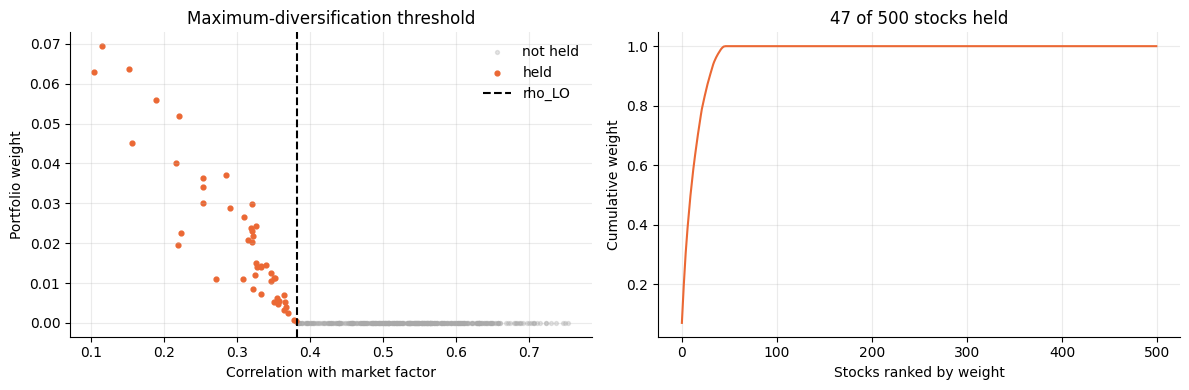

In [4]:
rho = np.sqrt(cov.sigmaM2) * cov.beta / cov.sigma
threshold = res_cf["rho_LO"]
rebuilt = (res_cf["sigma2"] / (cov.sigma @ x)) * cov.sigma / cov.omega2 \
          * np.maximum(1.0 - rho / threshold, 0.0)
np.testing.assert_allclose(x, rebuilt, rtol=1e-8, atol=1e-10)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
held = x > 0
ax[0].scatter(rho[~held], x[~held], s=8, alpha=0.3, color="darkgrey", label="not held")
ax[0].scatter(rho[held], x[held], s=12, color=COLORS["max_div"], label="held")
ax[0].axvline(threshold, color="black", linestyle="--", label="rho_LO")
ax[0].set(xlabel="Correlation with market factor", ylabel="Portfolio weight",
          title="Maximum-diversification threshold")
ax[0].legend(frameon=False)
ax[1].plot(np.cumsum(np.sort(x)[::-1]), color=COLORS["max_div"])
ax[1].set(xlabel="Stocks ranked by weight", ylabel="Cumulative weight",
          title=f"{held.sum()} of {cov.n} stocks held")
plt.tight_layout()
plt.show()

### Record the out-of-sample month

In [5]:
t_next = idx[i_first + 1]
r_next = rets.loc[t_next, universe].fillna(float(rf.loc[t_next])).values
print(f"{t_next}: total return {float(x @ r_next):.2%}; "
      f"excess return {float(x @ r_next) - rf.loc[t_next]:.2%}")

199501: total return -1.19%; excess return -1.61%


## 4. Full rolling backtest

MaxDiv enters `rolling_backtest` through the same constructor interface as minimum
risk and risk parity. All use monthly rebalancing, the shared covariance estimate,
and the same universe selection. Missing next-month returns earn the risk-free
rate; turnover compares new weights with the previous portfolio's drifted weights.

This notebook runs MaxDiv independently. The final comparison can include its
constructor alongside the other strategies in the same loop.

In [6]:
CONSTRUCTORS = {"max_div": max_diversification_closed_form}

t0 = time.perf_counter()
panel, weights = rolling_backtest(rets, caps, mkt, rf, T=T, n=N,
                                  start=idx[i_first], end=idx[i_last],
                                  constructors=CONSTRUCTORS)
returns = returns_from_panel(panel)
check_alignment(returns, weights, asset_returns=rets)
assert len(returns) == i_last - i_first + 1
print(f"backtest: {time.perf_counter() - t0:.2f}s; {len(returns)} months")

backtest: 2.52s; 372 months


## 5. Performance table

The shared evaluation uses geometric annualised returns, excess-return volatility
and Sharpe, compounded drawdowns, and drifted one-way turnover. As in the
risk-parity notebook, the table is checked against `backtest.summarize`.

The shared drawdown functions currently omit initial wealth of 1 from the
running peak, understating the early drawdown when the first month loses money.
Including that initial peak leaves this sample's maximum drawdown unchanged at
−53.62%; the early part of the curve needs a common evaluation-layer correction.

In [7]:
table = performance_table(returns, weights, rf=rf, asset_returns=rets, mkt=mkt)
ref = summarize(panel)
for col in ["ann_return", "ann_vol", "sharpe", "max_drawdown", "ann_turnover"]:
    assert np.abs(table[col] - ref.loc[table.index, col]).max() < 1e-12

display(table.rename(index=LABELS))

,months,ann_return,ann_vol,sharpe,max_drawdown,cum_return,ann_turnover,beta
Maximum diversification,372.0000,0.1035,0.1411,0.6037,-0.5362,20.1562,1.6036,0.6725


## 6. Cumulative returns, drawdowns and subperiods

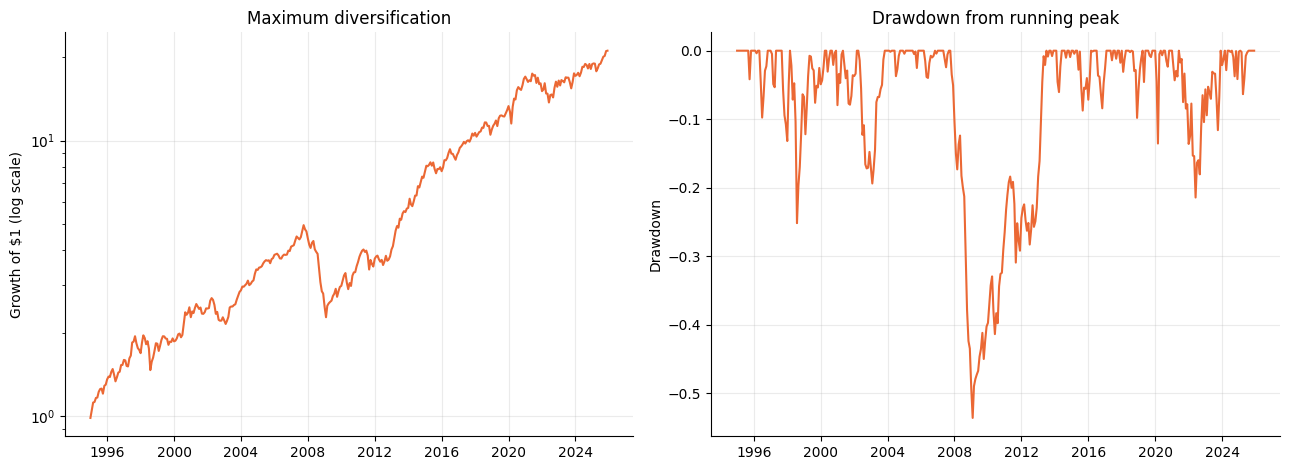

In [8]:
when = pd.PeriodIndex(returns.index.astype(str), freq="M").to_timestamp()
wealth = 1.0 + cumulative_returns(returns)
dd = drawdowns(returns)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].plot(when, wealth["max_div"], color=COLORS["max_div"])
ax[0].set(yscale="log", ylabel="Growth of $1 (log scale)", title="Maximum diversification")
ax[1].plot(when, dd["max_div"], color=COLORS["max_div"])
ax[1].set(ylabel="Drawdown", title="Drawdown from running peak")
plt.tight_layout()
plt.show()

In [9]:
PERIODS = [(199501, 199912, "1995-1999"), (200001, 200912, "2000-2009"),
           (201001, 201912, "2010-2019"), (202001, 202512, "2020-2025")]
sub = subperiod_table(returns, weights, periods=PERIODS, rf=rf, asset_returns=rets, mkt=mkt)
display(sub[["ann_return", "ann_vol", "sharpe", "max_drawdown", "beta"]]
        .rename(index=LABELS, level="strategy"))

,,ann_return,ann_vol,sharpe,max_drawdown,beta
period,strategy,,,,,
1995-1999,Maximum diversification,0.1391,0.1639,0.5760,-0.2518,0.9512
2000-2009,Maximum diversification,0.0439,0.1353,0.1855,-0.5362,0.5136
2010-2019,Maximum diversification,0.1589,0.1252,1.2065,-0.1539,0.7482
2020-2025,Maximum diversification,0.0862,0.1536,0.4418,-0.2144,0.7069


## 7. Diversification and risk concentration

Re-estimate each rebalance covariance using the same window and universe, as in
the risk-parity notebook. Equal weight on that universe is a diagnostic reference.

* DR measures diversification relative to weighted standalone asset volatility.
* `eff_n_weight` measures weight concentration; `eff_n_risk` measures concentration
  of stock risk contributions, rather than the number of independent risk sources.
* `systematic_share` is the market factor's share of model-implied variance.

Maximizing DR can produce a concentrated portfolio. It also does not imply the
lowest realized volatility or the highest Sharpe ratio.

In [10]:
covs = estimate_covs(weights["max_div"], rets, mkt, rf, T=T)
w_ew = weights["max_div"].notna().astype(float)
w_ew = w_ew.div(w_ew.sum(axis=1), axis=0).where(weights["max_div"].notna())
diag_weights = {"max_div": weights["max_div"], "ew": w_ew}
conc = {name: risk_concentration(w, covs) for name, w in diag_weights.items()}

for name, w in diag_weights.items():
    conc[name]["div_ratio"] = pd.Series({
        t: diversification_ratio(w.loc[t].reindex(c.permno).values, c)
        for t, c in covs.items()
    })

dr = pd.DataFrame({name: c.div_ratio for name, c in conc.items()})
assert (dr["ew"] - dr["max_div"]).max() < 1e-6
max_kkt = max(max(optimality_residuals(
    weights["max_div"].loc[t].reindex(c.permno).values, c).values())
    for t, c in covs.items())
assert max_kkt < 1e-8
print(f"Maximum KKT residual across rebalances: {max_kkt:.1e}")

cols = ["div_ratio", "n_held", "eff_n_weight", "eff_n_risk", "top10_rc_share", "systematic_share"]
diagnostic_summary = pd.DataFrame({LABELS[name]: c[cols].mean() for name, c in conc.items()}).T
display(diagnostic_summary)

Maximum KKT residual across rebalances: 2.8e-09


,div_ratio,n_held,eff_n_weight,eff_n_risk,top10_rc_share,systematic_share
Maximum diversification,3.6607,63.0430,36.7298,37.9566,0.4113,0.6548
Equally weighted,2.1167,500.0000,500.0000,437.0646,0.0453,0.9912


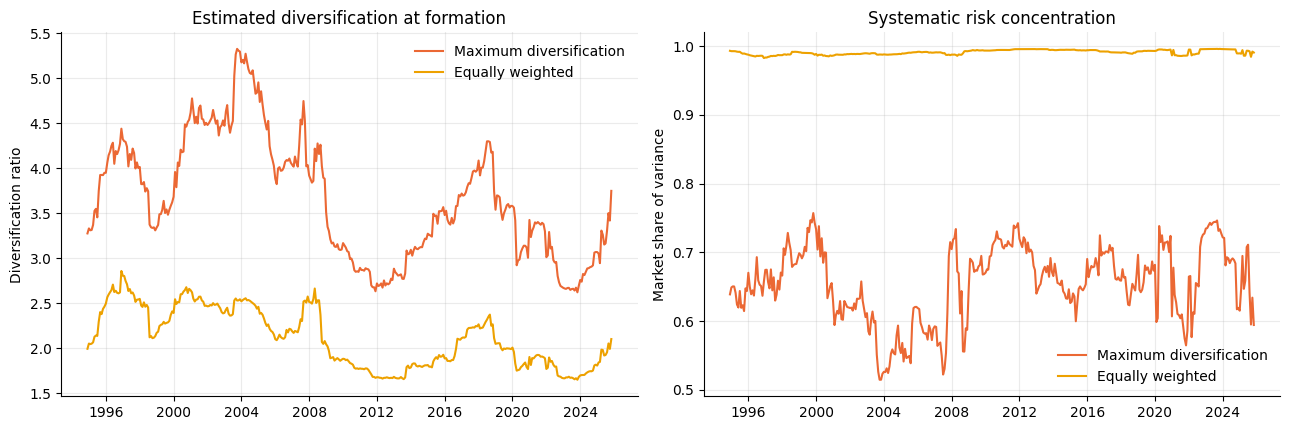

In [11]:
reb = pd.PeriodIndex(dr.index.astype(str), freq="M").to_timestamp()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for name, c in conc.items():
    ax[0].plot(reb, c.div_ratio, color=COLORS[name], label=LABELS[name])
    ax[1].plot(reb, c.systematic_share, color=COLORS[name], label=LABELS[name])
ax[0].set(ylabel="Diversification ratio", title="Estimated diversification at formation")
ax[1].set(ylabel="Market share of variance", title="Systematic risk concentration")
ax[0].legend(frameon=False)
ax[1].legend(frameon=False)
plt.tight_layout()
plt.show()

## Summary

* The QP and threshold solution agree on the first real rebalance; equation (4)
  reconstructs the weights, and KKT conditions hold across all 372 rebalances.
* Over 1995–2025, MaxDiv earns **10.35%** annualised return at **14.11%** volatility,
  with a Sharpe ratio of **0.604**, maximum drawdown of **−53.62%**, and annual
  one-way turnover of **160.36%**.
* The average estimated DR is **3.661**, compared with **2.117** for EW. MaxDiv
  holds about **63 of 500 stocks**, with effective weight N near **37** and a
  market share of model-implied variance near **65%**. A higher DR can coexist
  with concentrated holdings and substantial market risk.
* Performance varies across regimes: Sharpe is **0.185** in 2000–2009 and
  **1.207** in 2010–2019. Ex-ante optimality does not guarantee strong realized returns.

MaxDiv shares its factor model, universe and evaluation conventions with minimum
risk and risk parity. The full EW/VW backtests and final five-strategy comparison
are handled separately. Position caps, transaction costs and alternative
covariance models are outside this component's scope.